# Generative AI-Based Pneumonia Detection and Report Generation System

**ME-CSE 2nd Semester

---

---
### Dataset
- **Source**: Chest X-Ray Images (Pneumonia) — Kaggle
- **Classes**: NORMAL, PNEUMONIA
- **Link**: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

>


---
## Step 0: Install Required Libraries

In [ ]:
# Install all required packages
!pip install -q tensorflow keras matplotlib seaborn scikit-learn opencv-python-headless pillow grad-cam google-generativeai tf-keras
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


---
## Step 1: Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from glob import glob
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

import google.generativeai as genai
import base64
import io

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"✅ GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow version: 2.19.0
✅ GPU Available: True


---
## Step 2: Mount Google Drive & Set Dataset Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!


In [ ]:
# ============================================================
# SET YOUR DATASET PATH HERE
# Update this path to where your dataset folder is in Drive
# ============================================================
BASE_DIR = '/content/drive/MyDrive/ME 2nd sem Projects/chest_xray/chest_xray'  # <-- Change if needed

TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'val')
TEST_DIR    = os.path.join(BASE_DIR, 'test')

# Verify paths exist
for path, name in [(TRAIN_DIR, 'Train'), (VAL_DIR, 'Val'), (TEST_DIR, 'Test')]:
    status = '✅' if os.path.exists(path) else '❌ NOT FOUND'
    print(f"{status} {name}: {path}")

# Model hyperparameters
IMG_SIZE    = 224
BATCH_SIZE  = 8
EPOCHS      = 10
NUM_CLASSES = 2
CLASSES     = ['NORMAL', 'PNEUMONIA']

print(f"\n📐 Image Size : {IMG_SIZE}x{IMG_SIZE}")
print(f"📦 Batch Size : {BATCH_SIZE}")
print(f"🔁 Epochs     : {EPOCHS}")

✅ Train: /content/drive/MyDrive/ME 2nd sem Projects/chest_xray/chest_xray/train
✅ Val: /content/drive/MyDrive/ME 2nd sem Projects/chest_xray/chest_xray/val
✅ Test: /content/drive/MyDrive/ME 2nd sem Projects/chest_xray/chest_xray/test

📐 Image Size : 224x224
📦 Batch Size : 8
🔁 Epochs     : 10


---
## Step 3: Exploratory Data Analysis (EDA)

📁 Dataset Distribution
-----------------------------------
Split          NORMAL    PNEUMONIA    Total
-----------------------------------
Train            1341         3876     5217
Val                 8            8       16
Test              234          390      624


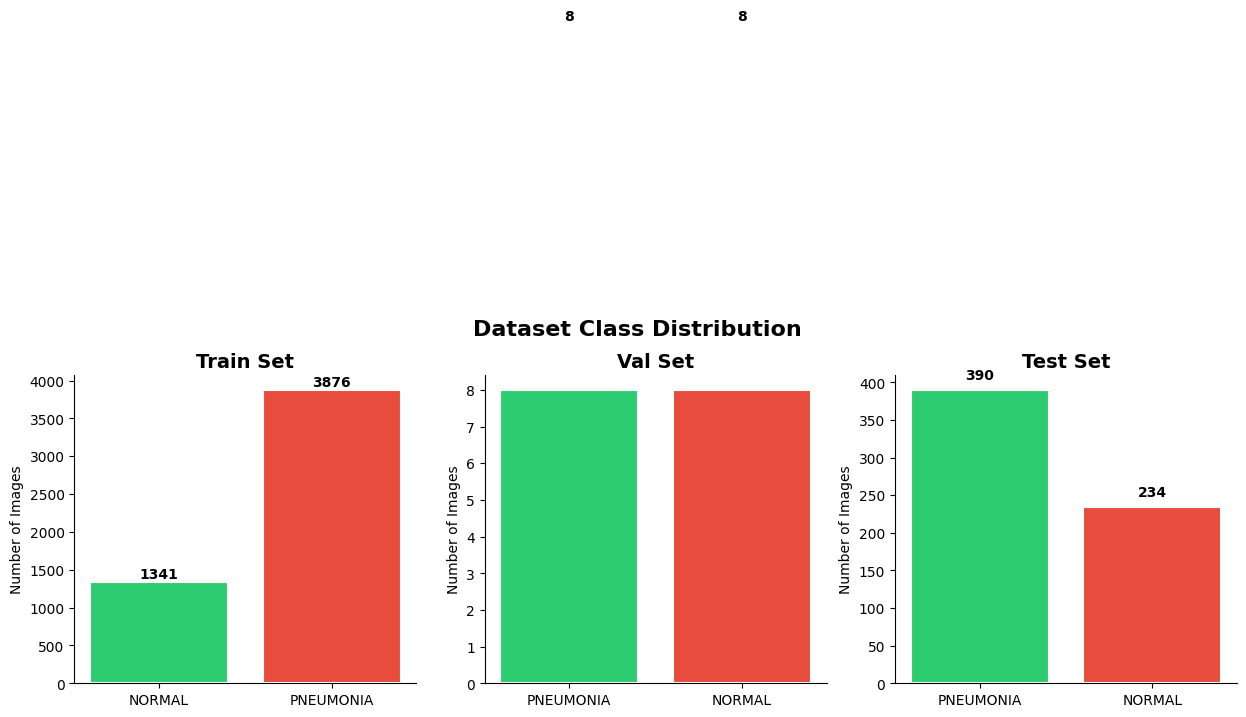

✅ EDA complete


In [ ]:
def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(glob(os.path.join(cls_path, '*')))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

print("📁 Dataset Distribution")
print("-" * 35)
print(f"{'Split':<10} {'NORMAL':>10} {'PNEUMONIA':>12} {'Total':>8}")
print("-" * 35)
for split, counts in [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]:
    n  = counts.get('NORMAL', 0)
    p  = counts.get('PNEUMONIA', 0)
    print(f"{split:<10} {n:>10} {p:>12} {n+p:>8}")

# Visualize distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split, counts) in zip(axes, [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{split} Set', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete")

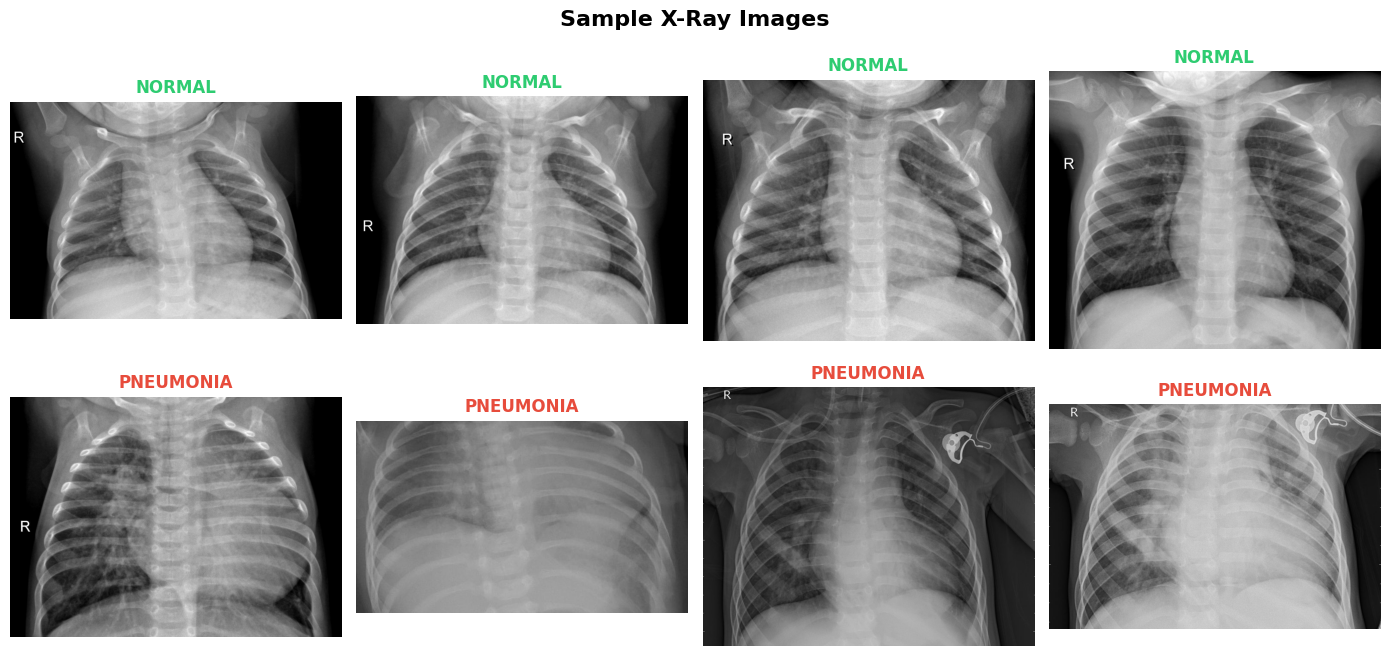

In [ ]:
# Visualize sample X-ray images
def show_samples(data_dir, n_per_class=4, title='Sample X-Ray Images'):
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 3.5, 7))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        cls_dir   = os.path.join(data_dir, cls)
        images    = glob(os.path.join(cls_dir, '*'))[:n_per_class]
        color     = '#2ecc71' if cls == 'NORMAL' else '#e74c3c'
        for col, img_path in enumerate(images):
            img = Image.open(img_path).convert('RGB')
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(cls, color=color, fontweight='bold')
            axes[row, col].axis('off')
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(TRAIN_DIR)

---
## Phase 1: Data Preprocessing & Augmentation

In [ ]:
# ── Training augmentation (mirrors Table 1 from the reference paper) ──
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Validation / Test: only rescale ──
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# ── Create generators ──
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("✅ Data generators created!")
print(f"   Train batches : {len(train_gen)}")
print(f"   Val   batches : {len(val_gen)}")
print(f"   Test  batches : {len(test_gen)}")
print(f"   Class indices : {train_gen.class_indices}")

Found 5217 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
✅ Data generators created!
   Train batches : 653
   Val   batches : 2
   Test  batches : 78
   Class indices : {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"Class Weights: {class_weight_dict}")

⚖️  Class Weights: {0: np.float64(1.9451901565995526), 1: np.float64(0.6729876160990712)}


---
## Phase 2: Model Architecture (EfficientNetB0 + DenseNet121 with Attention Ensemble)


In [ ]:
# ─────────────────────────────────────────────────────
# 2.1 Feature Fusion Block (Channel-Attention based)
# ─────────────────────────────────────────────────────
def feature_fusion(f_eff, f_dense):
    """
    Fuses EfficientNet & DenseNet features using channel attention.
    Algorithm 1 from reference paper.
    """
    # Channel attention weights via sigmoid conv
    eff_att   = layers.Conv2D(f_eff.shape[-1],   (1,1), activation='sigmoid', padding='same')(f_eff)
    dense_att = layers.Conv2D(f_dense.shape[-1], (1,1), activation='sigmoid', padding='same')(f_dense)

    f_eff   = layers.Multiply()([f_eff,   eff_att])
    f_dense = layers.Multiply()([f_dense, dense_att])

    # Global Average Pooling
    f_eff   = layers.GlobalAveragePooling2D()(f_eff)
    f_dense = layers.GlobalAveragePooling2D()(f_dense)

    # Project to common space (784 = 7×7×16)
    f_eff   = layers.Dense(784, activation='relu')(f_eff)
    f_dense = layers.Dense(784, activation='relu')(f_dense)
    f_eff   = layers.Dropout(0.23)(f_eff)
    f_dense = layers.Dropout(0.23)(f_dense)

    fused    = layers.Add()([f_eff, f_dense])
    reshaped = layers.Reshape((7, 7, 16))(fused)
    return reshaped


# ─────────────────────────────────────────────────────
# 2.2 Residual Block
# ─────────────────────────────────────────────────────
def residual_block(x, filters=256):
    shortcut = layers.Conv2D(filters, (1,1), padding='same')(x)
    shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    return x


# ─────────────────────────────────────────────────────
# 2.3 Attention Augmentation Block
# ─────────────────────────────────────────────────────
def attention_augmentation(x):
    """
    Algorithm 2 from reference paper.
    """
    channels = x.shape[-1]

    # Flatten for dense operations
    flat = layers.Flatten()(x)

    a = layers.Dense(flat.shape[-1], activation='relu')(flat)
    a = layers.BatchNormalization()(a)
    a = layers.Dropout(0.23)(a)
    a = layers.Dense(flat.shape[-1], activation='sigmoid')(a)
    a = layers.BatchNormalization()(a)
    a = layers.Dropout(0.23)(a)

    weighted = layers.Multiply()([flat, a])
    return weighted


# ─────────────────────────────────────────────────────
# 2.4 Dynamic Attention Pooling
# ─────────────────────────────────────────────────────
def dynamic_attention_pooling(x):
    """
    Algorithm 3 from reference paper.
    """
    a_map   = layers.Conv2D(1, (1,1), activation='sigmoid', padding='same')(x)
    weighted = layers.Multiply()([x, a_map])
    pooled   = layers.GlobalAveragePooling2D()(weighted)
    return pooled


print("✅ All architectural blocks defined!")

✅ All architectural blocks defined!


In [ ]:
# ─────────────────────────────────────────────────────
# 2.5 Build Complete Model
# ─────────────────────────────────────────────────────
def build_attention_ensemble_model(img_size=224, num_classes=2):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='xray_input')

    # ── Base Networks (pre-trained on ImageNet, frozen initially) ──
    eff_base   = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)
    dense_base = DenseNet121(include_top=False, weights='imagenet', input_tensor=inputs)

    eff_base.trainable   = False
    dense_base.trainable = False

    f_eff   = eff_base.output    # (7, 7, 1280)
    f_dense = dense_base.output  # (7, 7, 1024)

    # ── Multi-Head Self-Attention on each backbone output ──
    # Reshape to (seq_len, features) for attention
    eff_seq   = layers.Reshape((49, 1280))(f_eff)
    dense_seq = layers.Reshape((49, 1024))(f_dense)

    eff_attn   = layers.MultiHeadAttention(num_heads=4, key_dim=128, name='mha_eff')(eff_seq, eff_seq)
    dense_attn = layers.MultiHeadAttention(num_heads=4, key_dim=128, name='mha_dense')(dense_seq, dense_seq)

    eff_attn   = layers.Reshape((7, 7, 1280))(eff_attn)
    dense_attn = layers.Reshape((7, 7, 1024))(dense_attn)

    # ── Feature Fusion ──
    fused = feature_fusion(eff_attn, dense_attn)     # (7, 7, 16)

    # ── Residual Block ──
    x = residual_block(fused, filters=256)

    # ── Attention Augmentation ──
    x = attention_augmentation(x)  # returns flattened weighted vector

    # ── Classifier Head ──
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(6.72e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.23)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs=[inputs, inputs], outputs=outputs, name='PneumoniaAttentionEnsemble')

    # Simpler functional API — single input
    inp    = keras.Input(shape=(img_size, img_size, 3), name='xray_input')

    f_eff_out   = eff_base(inp, training=False)
    f_dense_out = dense_base(inp, training=False)

    eff_seq2   = layers.Reshape((49, 1280))(f_eff_out)
    dense_seq2 = layers.Reshape((49, 1024))(f_dense_out)

    eff_attn2   = layers.MultiHeadAttention(num_heads=4, key_dim=128)(eff_seq2,   eff_seq2)
    dense_attn2 = layers.MultiHeadAttention(num_heads=4, key_dim=128)(dense_seq2, dense_seq2)

    eff_attn2   = layers.Reshape((7, 7, 1280))(eff_attn2)
    dense_attn2 = layers.Reshape((7, 7, 1024))(dense_attn2)

    fused2 = feature_fusion(eff_attn2, dense_attn2)
    x2     = residual_block(fused2, filters=64)
    x2     = attention_augmentation(x2)
    x2     = layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(6.72e-3))(x2)
    x2     = layers.BatchNormalization()(x2)
    x2     = layers.Dropout(0.23)(x2)
    out2   = layers.Dense(num_classes, activation='softmax', name='predictions')(x2)

    final_model = keras.Model(inputs=inp, outputs=out2, name='PneumoniaAttentionEnsemble')
    return final_model


model = build_attention_ensemble_model(IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=7.47e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n✅ Model compiled successfully!")

Model: "PneumoniaAttentionEnsemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ xray_input[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ xray_input[0][0]  │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 49, 1280)  │          0 │ efficientnetb0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 49, 1024)  │          0 │ densenet121[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1280)  │  2,624,256 │ reshape_5[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1024)  │  2,099,712 │ reshape_6[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 7, 7,      │          0 │ multi_head_atten… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 7, 7,      │          0 │ multi_head_atten… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7,      │  1,639,680 │ reshape_7[0][0]   │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7,      │  1,049,600 │ reshape_8[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 7, 7,      │          0 │ reshape_7[0][0],  │
│ (Multiply)          │ 1280)             │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 7, 7,      │          0 │ reshape_8[0][0],  │
│ (Multiply)          │ 1024)             │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_3[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ multiply_4[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 784)       │  1,004,304 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 784)       │    803,600 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 784)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 40,458,949 (154.34 MB)

 Trainable params: 29,358,690 (111.99 MB)

 Non-trainable params: 11,100,259 (42.34 MB)


✅ Model compiled successfully!


---
## Phase 2 (cont.): Model Training

In [ ]:
# ── Callbacks ──
MODEL_SAVE_PATH = '/content/drive/MyDrive/ME 2nd sem Projects/pneumonia_model_best.h5'

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Starting Training...")
print("-" * 50)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete! Best model saved to Google Drive.")

🚀 Starting Training...
--------------------------------------------------
Epoch 1/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6879 - loss: 2.2593
Epoch 1: val_accuracy improved from None to 0.87500, saving model to /content/drive/MyDrive/ME 2nd sem Projects/pneumonia_model_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/ME 2nd sem Projects/pneumonia_model_best.h5
653/653 ━━━━━━━━━━━━━━━━━━━━ 3843s 6s/step - accuracy: 0.7447 - loss: 2.0893 - val_accuracy: 0.8750 - val_loss: 1.7785 - learning_rate: 7.4700e-05
Epoch 2/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8356 - loss: 1.7555
Epoch 2: val_accuracy did not improve from 0.87500
653/653 ━━━━━━━━━━━━━━━━━━━━ 160s 244ms/step - accuracy: 0.8440 - loss: 1.6964 - val_accuracy: 0.8750 - val_loss: 1.6838 - learning_rate: 7.4700e-05
Epoch 3/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8724 - loss: 1.5128
Epoch 3: val_accuracy did not improve from 0.87500
653/653 ━━━━━━━━━━━━━━━━━━━━ 151s 231ms/step - accuracy: 0.8882 - loss: 1.4367 - val_accuracy: 0.7500 - val_loss: 1.3683 - learning_rate: 7.4700e-05
Epoch 4/10
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9013 - loss: 1.2850
Epoch 4: val_accuracy did not improve from 0.87500
653/653 ━━━━━━━━━━━━━━━━━━━━ 151s 23

In [ ]:
cnn_model = model
print("✅ CNN model stored safely")
print(type(cnn_model))  # Debug check

✅ CNN model stored safely
<class 'keras.src.models.functional.Functional'>


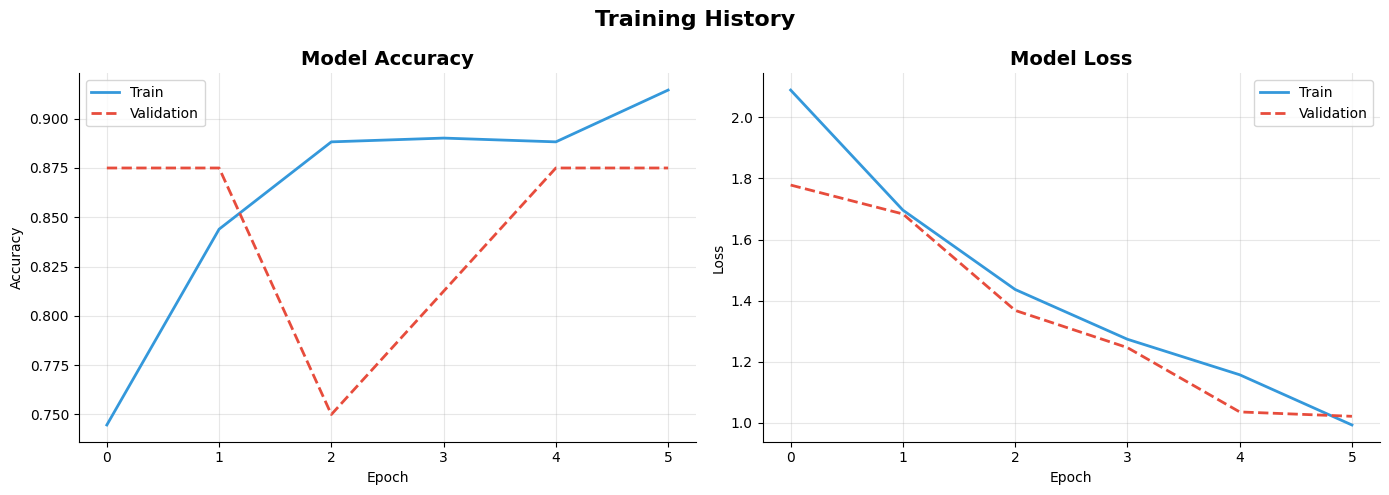

In [ ]:
# ── Plot Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes,
    ['accuracy', 'loss'],
    ['Model Accuracy', 'Model Loss']):
    ax.plot(history.history[metric],     label='Train',      linewidth=2, color='#3498db')
    ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2, color='#e74c3c', linestyle='--')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model Evaluation on Test Set

In [ ]:
# ── Predictions ──
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

# ── Metrics ──
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
auc       = roc_auc_score(y_true, y_pred_probs[:, 1])
specificity_val = (confusion_matrix(y_true, y_pred)[0, 0] /
                   (confusion_matrix(y_true, y_pred)[0, 0] + confusion_matrix(y_true, y_pred)[0, 1]))

print("📊 Test Set Performance Metrics")
print("=" * 40)
print(f"  Accuracy    : {accuracy*100:.2f}%")
print(f"  Precision   : {precision*100:.2f}%")
print(f"  Recall      : {recall*100:.2f}%")
print(f"  F1 Score    : {f1*100:.2f}%")
print(f"  Specificity : {specificity_val*100:.2f}%")
print(f"  AUC         : {auc:.4f}")
print("=" * 40)

78/78 ━━━━━━━━━━━━━━━━━━━━ 482s 6s/step
📊 Test Set Performance Metrics
  Accuracy    : 88.14%
  Precision   : 94.13%
  Recall      : 86.41%
  F1 Score    : 90.11%
  Specificity : 91.03%
  AUC         : 0.9470


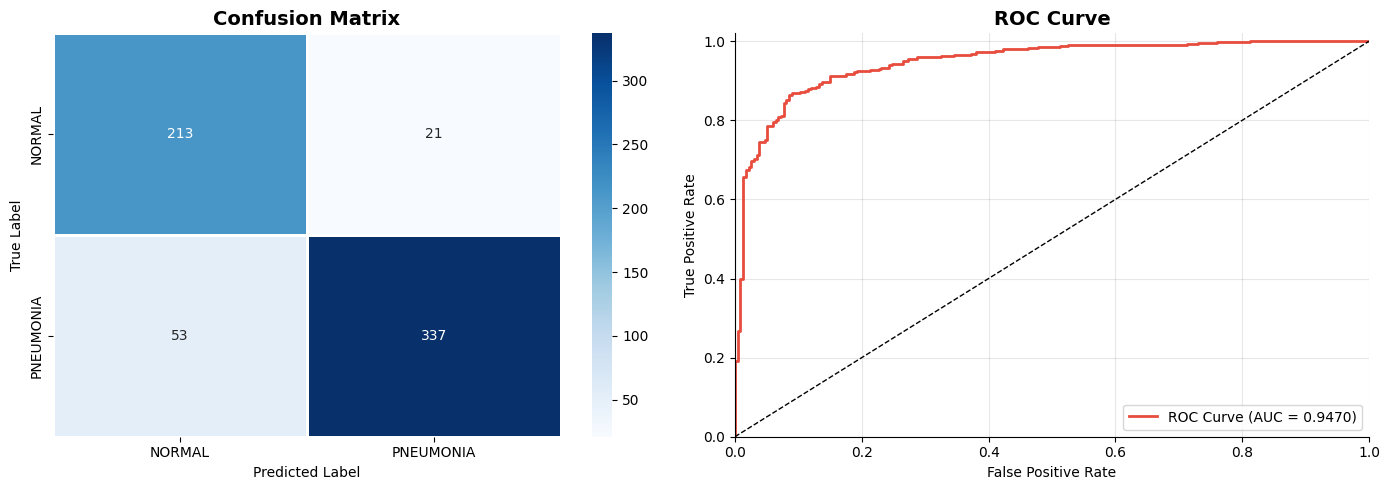

In [ ]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Phase 3: Explainable AI — Grad-CAM Visualization

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a given image and model.
    Highlights regions that contributed to the prediction.
    """
    grad_model = keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_out, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_out = last_conv_out[0]
    heatmap = last_conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, model, last_conv_layer='top_conv', alpha=0.4):
    """
    Overlays Grad-CAM heatmap on the original X-ray image.
    """
    # Load and preprocess
    img    = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr    = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    inp    = np.expand_dims(arr, axis=0)

    # Prediction
    preds      = model.predict(inp, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100
    label      = CLASSES[pred_class]

    # Grad-CAM
    heatmap = make_gradcam_heatmap(inp, model, last_conv_layer, pred_index=pred_class)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_rgb     = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_rgb     = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)

    orig_rgb  = np.uint8(255 * arr)
    superimposed = cv2.addWeighted(orig_rgb, 1 - alpha, heatmap_rgb, alpha, 0)

    return orig_rgb, heatmap_rgb, superimposed, label, confidence


def visualize_gradcam_grid(image_paths, model, last_conv_layer='top_conv'):
    n = len(image_paths)
    fig, axes = plt.subplots(n, 3, figsize=(13, 4 * n))
    if n == 1:
        axes = [axes]

    col_titles = ['Original X-Ray', 'Grad-CAM Heatmap', 'Overlay (Infected Regions)']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=12, fontweight='bold')

    for row, img_path in enumerate(image_paths):
        orig, heatmap, overlay, label, conf = overlay_gradcam(img_path, model, last_conv_layer)
        color = '#2ecc71' if label == 'NORMAL' else '#e74c3c'

        for col, (img_data, title) in enumerate(zip(
            [orig, heatmap, overlay],
            ['Original', 'Heatmap', 'Overlay']
        )):
            axes[row][col].imshow(img_data)
            axes[row][col].axis('off')

        axes[row][2].set_title(
            f'Prediction: {label} ({conf:.1f}%)',
            color=color, fontweight='bold', fontsize=11
        )

    plt.suptitle('Grad-CAM: Explainable AI Visualization', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


print("✅ Grad-CAM functions defined!")

✅ Grad-CAM functions defined!


🔎 Using conv layer for Grad-CAM: 'conv2d_7'


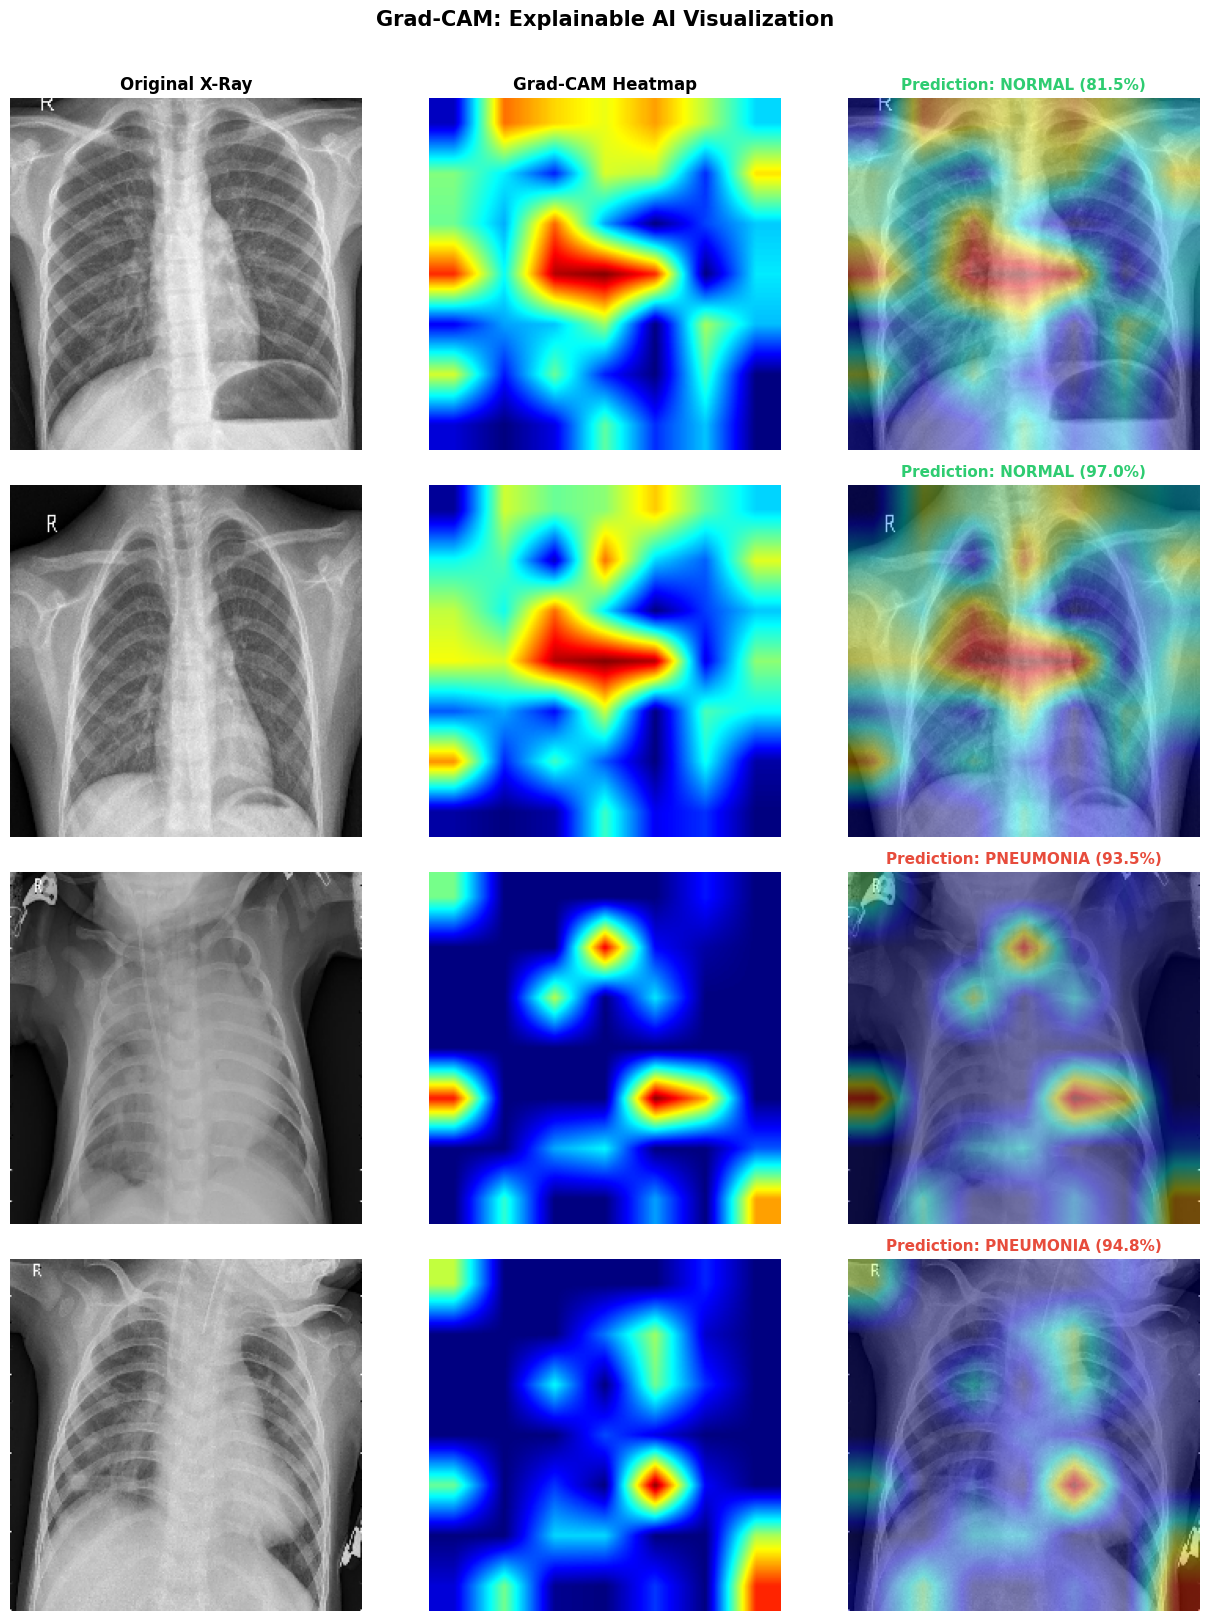

In [ ]:
# ── Run Grad-CAM on sample test images ──
# Find the last convolutional layer name in EfficientNetB0 branch
conv_layers = [l.name for l in model.layers if 'conv' in l.name.lower()]
last_conv   = conv_layers[-1] if conv_layers else 'top_conv'
print(f"🔎 Using conv layer for Grad-CAM: '{last_conv}'")

# Collect a few test images (2 pneumonia, 2 normal)
sample_images = []
for cls in ['NORMAL', 'PNEUMONIA']:
    imgs = glob(os.path.join(TEST_DIR, cls, '*'))[:2]
    sample_images.extend(imgs)

visualize_gradcam_grid(sample_images, model, last_conv_layer=last_conv)

---
##  Phase 4: Generative AI Medical Report Generation


In [ ]:
# ── Gemini API Setup ──
import google.generativeai as genai
from google.colab import userdata

# Load API key from Colab Secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# Configure Gemini
genai.configure(api_key=GEMINI_API_KEY)

print("✅ Gemini API ready")

✅ Gemini API ready


In [ ]:
def generate_medical_report(img_path, model):
    """
    Generates a structured medical report using:
    1. CNN model prediction
    2. Gemini LLM for report generation (GenAI)
    """

    # ── Step 1: Validate model ──
    if not hasattr(model, "predict"):
        raise ValueError("❌ Provided model is not a valid CNN model")

    # ── Step 2: Load & preprocess image ──
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    inp = np.expand_dims(arr, axis=0)

    preds = model.predict(inp, verbose=0)

    # ── Step 3: Extract probabilities safely ──
    normal_conf    = float(preds[0][0]) * 100
    pneumonia_conf = float(preds[0][1]) * 100

    pred_label = 'PNEUMONIA' if pneumonia_conf > normal_conf else 'NORMAL'
    pred_conf  = max(normal_conf, pneumonia_conf)

    # Risk levels
    if pneumonia_conf >= 80:
        risk_level = 'HIGH'
    elif pneumonia_conf >= 50:
        risk_level = 'MEDIUM'
    else:
        risk_level = 'LOW'

    # Confidence interpretation
    confidence_note = (
        "High confidence prediction"
        if pred_conf > 85 else
        "Moderate confidence prediction"
        if pred_conf > 60 else
        "Low confidence - needs verification"
    )

    # ── Step 4: Build Prompt ──
    prompt = f"""
You are an expert radiologist AI assistant.

A deep learning model analyzed a chest X-ray.

RESULTS:
- Diagnosis: {pred_label}
- Confidence: {pred_conf:.1f}%
- Risk Level: {risk_level}
- Note: {confidence_note}

Generate a professional medical report with:

1. Patient Radiology Report
2. Examination Type
3. AI Findings Summary
4. Clinical Interpretation
5. Possible Conditions (Differential Diagnosis)
6. Recommended Actions
7. Disclaimer (AI-assisted, not a final diagnosis)

Make it:
- medically accurate
- concise but informative
- understandable for a general user
"""

    # ── Step 5: Call Gemini (GenAI) ──
    try:
        gemini = genai.GenerativeModel("gemini-3-flash-preview")

        response = gemini.generate_content(prompt)

        report_text = response.text.strip()

    except Exception as e:
        report_text = f"⚠️ Error generating report: {str(e)}"

    # ── Step 6: Display ──
    print("\n" + "═" * 65)
    print("          🏥 AI-GENERATED MEDICAL REPORT")
    print("═" * 65)
    print(f"Prediction : {pred_label}")
    print(f"Confidence : {pred_conf:.1f}%")
    print(f"Risk Level : {risk_level}")
    print("─" * 65)
    print(report_text)
    print("═" * 65)

    return {
        'prediction': pred_label,
        'confidence': pred_conf,
        'risk_level': risk_level,
        'report': report_text
    }

print("✅ Final Gemini-based GenAI function ready!")

✅ Final Gemini-based GenAI function ready!


In [ ]:
# ── Generate a report for a sample test image ──
sample_pneumonia = glob(os.path.join(TEST_DIR, 'PNEUMONIA', '*'))[0]

# --- Debugging: List available Gemini models --- #
print("\n--- Available Gemini Models ---")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(f"  Model: {m.name} (supports generateContent)")
    else:
        print(f"  Model: {m.name}")
print("-------------------------------")

report_result = generate_medical_report(sample_pneumonia, cnn_model)


--- Available Gemini Models ---
  Model: models/gemini-2.5-flash (supports generateContent)
  Model: models/gemini-2.5-pro (supports generateContent)
  Model: models/gemini-2.0-flash (supports generateContent)
  Model: models/gemini-2.0-flash-001 (supports generateContent)
  Model: models/gemini-2.0-flash-lite-001 (supports generateContent)
  Model: models/gemini-2.0-flash-lite (supports generateContent)
  Model: models/gemini-2.5-flash-preview-tts (supports generateContent)
  Model: models/gemini-2.5-pro-preview-tts (supports generateContent)
  Model: models/gemma-3-1b-it (supports generateContent)
  Model: models/gemma-3-4b-it (supports generateContent)
  Model: models/gemma-3-12b-it (supports generateContent)
  Model: models/gemma-3-27b-it (supports generateContent)
  Model: models/gemma-3n-e4b-it (supports generateContent)
  Model: models/gemma-3n-e2b-it (supports generateContent)
  Model: models/gemma-4-26b-a4b-it (supports generateContent)
  Model: models/gemma-4-31b-it (support

ERROR:tornado.access:503 POST /v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3197.24ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 4134.84ms



═════════════════════════════════════════════════════════════════
          🏥 AI-GENERATED MEDICAL REPORT
═════════════════════════════════════════════════════════════════
Prediction : PNEUMONIA
Confidence : 93.5%
Risk Level : HIGH
─────────────────────────────────────────────────────────────────
**RADIOLOGY REPORT: CHEST X-RAY ANALYSIS**

**Patient ID:** [INSERT ID]
**Date of Examination:** October 26, 2023
**Referring Physician:** [INSERT NAME]

---

### 1. Patient Radiology Report
**Clinical History:** Patient presents with symptoms requiring pulmonary evaluation (e.g., persistent cough, fever, or dyspnea). 
**Comparison:** None available.

### 2. Examination Type
**Procedure:** Chest X-Ray (CXR) 
**Views:** Posterior-Anterior (PA) and Lateral views.

### 3. AI Findings Summary
*   **Primary Diagnosis:** Pneumonia
*   **AI Confidence Score:** 93.5% (High Confidence)
*   **Risk Level:** High
*   **Observations:** The deep learning model has identified significant opacification and p

---
##  Full Inference Pipeline: Single Image → Report + Grad-CAM


📸 Analyzing: person100_bacteria_478.jpeg



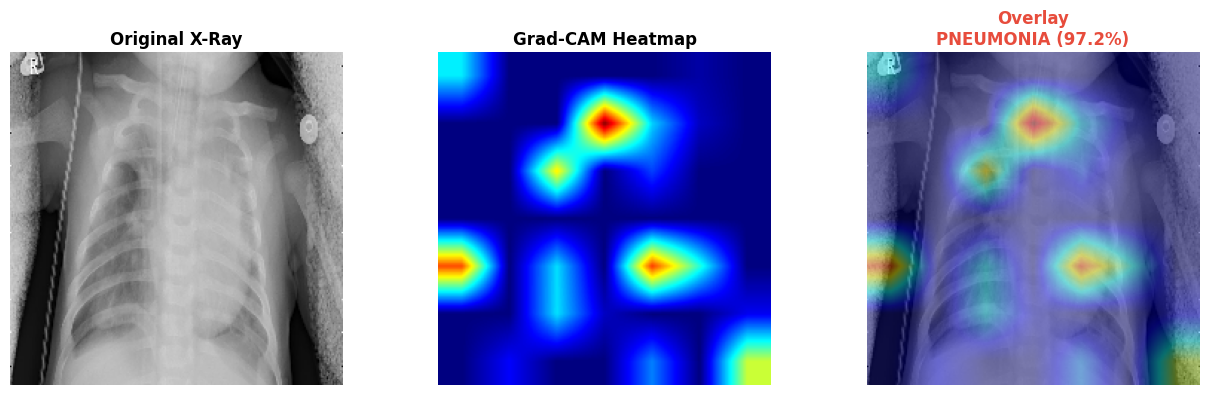


═════════════════════════════════════════════════════════════════
          🏥 AI-GENERATED MEDICAL REPORT
═════════════════════════════════════════════════════════════════
Prediction : PNEUMONIA
Confidence : 97.2%
Risk Level : HIGH
─────────────────────────────────────────────────────────────────
**RADIOLOGY REPORT: ARTIFICIAL INTELLIGENCE ANALYSIS**

**1. Patient Radiology Report**
*   **Report ID:** CXR-AI-99284
*   **Status:** Preliminary AI Analysis
*   **Priority:** HIGH (Urgent Review Recommended)
*   **Date:** October 26, 2023

**2. Examination Type**
*   **Procedure:** Chest X-Ray (CXR) 
*   **Views:** Posteroanterior (PA) and Lateral

**3. AI Findings Summary**
*   **Primary Detection:** Pneumonia
*   **AI Confidence Score:** 97.2%
*   **Risk Level:** HIGH
*   **Automated Note:** The deep learning model has identified significant patterns of lung opacification with very high statistical confidence. Immediate clinical correlation is required.

**4. Clinical Interpretation**
Th

In [ ]:
def full_pipeline(img_path, model, last_conv_layer='top_conv'):
    """
    Complete end-to-end inference:
      1. Predict class
      2. Generate Grad-CAM
      3. Generate medical report with Gemini
      4. Launch chatbot session
    """
    print(f"\n📸 Analyzing: {os.path.basename(img_path)}\n")

    # ── Grad-CAM Visualization ──
    orig, heatmap, overlay, label, confidence = overlay_gradcam(
        img_path, model, last_conv_layer
    )

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    color = '#2ecc71' if label == 'NORMAL' else '#e74c3c'
    for ax, img_data, title in zip(axes,
        [orig, heatmap, overlay],
        ['Original X-Ray', 'Grad-CAM Heatmap', f'Overlay\n{label} ({confidence:.1f}%)']):
        ax.imshow(img_data)
        ax.set_title(title, fontsize=12, fontweight='bold',
                     color=color if 'Overlay' in title else 'black')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('full_pipeline_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Generate Report ──
    report = generate_medical_report(img_path, model)
    return report


# ── Run the full pipeline on a test image ──
test_image = glob(os.path.join(TEST_DIR, 'PNEUMONIA', '*'))[2]
result     = full_pipeline(test_image, model, last_conv_layer=last_conv)

---
## Save & Export

In [ ]:
# ── Save model in multiple formats ──
DRIVE_SAVE_DIR = '/content/drive/MyDrive/ME 2nd sem Projects/PneumoniaProject/'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

# Keras format
model.save(os.path.join(DRIVE_SAVE_DIR, 'pneumonia_attention_model.keras'))
print("✅ Model saved in Keras format")

# H5 format
model.save(os.path.join(DRIVE_SAVE_DIR, 'pneumonia_attention_model.h5'))
print("✅ Model saved in H5 format")

# Save plots to Drive
import shutil
for fname in ['class_distribution.png', 'sample_images.png',
               'training_history.png', 'confusion_roc.png',
               'gradcam_visualization.png', 'full_pipeline_result.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(DRIVE_SAVE_DIR, fname))
        print(f"   📊 {fname} saved to Drive")

print(f"\n✅ All outputs saved to: {DRIVE_SAVE_DIR}")

✅ Model saved in Keras format
✅ Model saved in H5 format
   📊 class_distribution.png saved to Drive
   📊 sample_images.png saved to Drive
   📊 training_history.png saved to Drive
   📊 confusion_roc.png saved to Drive
   📊 gradcam_visualization.png saved to Drive
   📊 full_pipeline_result.png saved to Drive

✅ All outputs saved to: /content/drive/MyDrive/ME 2nd sem Projects/PneumoniaProject/
